# Beyond BLAST

In [ ]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Base.Threads
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using FastTransforms
using Dates
using TOML
using Plots
using Plots.Measures
using QuadGK
using LaTeXStrings
using Tullio
using StaticArrays
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using CSV
using DataFrames
using JSON

[ Info: Precompiling DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0]
Precompiling packages...
   1997.8 ms  ✓ DataInterpolations → DataInterpolationsChainRulesCoreExt
  1 dependency successfully precompiled in 3 seconds. 37 already precompiled.
[ Info: Precompiling DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd]
┌ Warning: Module DataInterpolations with build ID fafbfcfd-454c-84f8-bb81-c602e26043dc is missing from the cache.
│ This may mean DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2022
[ Info: Skipping precompilation since __precompile__(false). Importing DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd].
Precompiling packages...
    563.5 ms  ✓ FastChebInterp
  1 dependency successfully precompiled in 1 seconds. 18 already precompiled.
[ Info: Precompiling FastChebInterp [cf66c380-9a80-432c-aff8-4f9c79c0bdde]
Precompi

In [216]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
using .Blast
using .blast_tutorials;
include("blast_code/src/galaxy_galaxy.jl")
#include("blast_code/src/galaxy_shear.jl")
include("blast_code/src/shear_shear.jl")
using .galaxy_galaxy
#using .galaxy_shear
using .shear_shear

In [83]:
timestamp = Dates.format(now(), "yyyy_mm_dd_HHMMSS")
output_dir = "out/runs/run_$timestamp"
plot_subdir = joinpath(output_dir, "plots")
Sl_plots = joinpath(plot_subdir, "Sl_plots")
Kernel_plots = joinpath(plot_subdir, "kernels")
quantity_subdir = joinpath(output_dir, "quantities")
chebcoefs = joinpath(quantity_subdir, "chebcoefs")
Sl = joinpath(quantity_subdir, "Sl")
mkpath(output_dir)
mkpath(plot_subdir)
mkpath(quantity_subdir)
mkpath(chebcoefs)
mkpath(Sl)
mkpath(Sl_plots)
mkpath(Kernel_plots)
println("Folders in place: ", output_dir, ", ", plot_subdir, " and ", quantity_subdir)

Folders in place: out/runs/run_2026_06_17_164210, out/runs/run_2026_06_17_164210/plots and out/runs/run_2026_06_17_164210/quantities


### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [217]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

#### Setting parameters

In [218]:
cosmo = Blast.FlatΛCDM()
n_chi = 96                                            # Number of comoving distance points
x_range = LinRange(26, 7000, n_chi)                   # in Mpc/h: from 26 Mpc/h to 7000 Mpc/h
z_range = z_of_χ.(x_range)
#ℓ = Blast.ℓ
ℓ = LinRange(2, 200, 100)
x_min = minimum(x_range)                              # minimum comoving distance [Mpc/h]
x_max = maximum(x_range)                              # maximum comoving distance [Mpc/h]
chi = LinRange(x_min, x_max, n_chi)                   # array of comoving distances [Mpc/h]
zed = z_of_χ.(chi)                                    # array of redshifts corresponding to the comoving distances
n_z = length(zed)
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_n5k = n5k_bins["z_cl"]
zmin = minimum(z_n5k)                                 # minimum redshift
zmax = maximum(z_n5k)                                 # maximum redshift
kmax = 200/13                                         # maximum wavenumber (small scales) [h/Mpc]
kmin = 2.5/x_max                                      # minimum wavenumber (large scales) [h/Mpc]
n_cheb = 119                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^15+1;

In [219]:
shear_prefac_W = shear_shear.shear_prefactor(x_range, z_range, cosmo; output_dir=output_dir);
shear_prefac_W_cheb = shear_shear.shear_prefactor_cheb(zmin, zmax, n_cheb, z_range, shear_prefac_W; output_dir=output_dir);
cheb_coeff_shear = shear_shear.compute_prefactor_chebcoeffs(shear_prefac_W_cheb; output_dir=output_dir);

Plot saved: out/runs/run_2026_06_17_164210/plots/kernels/chi_vs_z_shear.png
Plot saved: out/runs/run_2026_06_17_164210/plots/kernels/nz_shear.png
Plot saved: out/runs/run_2026_06_17_164210/plots/kernels/lensing_efficiency.png
Wrote W(z) shear prefactor on Chebyshev grid to: out/runs/run_2026_06_17_164210/quantities/prefac_on_cheb_shear.npy
Wrote W(z) Chebyshev coefficients to: out/runs/run_2026_06_17_164210/quantities/W_cheb_coeff_shear.npy


Defining the kernel/window function for a galaxy probe: the window function is \
\
$W(z) = n(z) \chi(z)^2 b(z) D(z) $ \
\
where \
\
$n(z) = A (\frac{z}{z_0})^{\alpha} exp[{-(\frac{z}{z_0})^{\beta}}] $, with $A = \frac{1.5}{z_0}$, $\alpha = 2$ and $\beta = 1.5$ \
\
$b(z) = b_0 \sqrt{1+z} $ and $b_0 = 1$ \
\
$D(z) = \frac{D(z)^{unnorm}}{D(0)^{unnorm}}$, with $D(z)^{unnorm} = E(z) \int_0^{\infty} dz' \frac{1+z'}{E(z')^3} $ 

In [220]:
gal_prefact_W, bias, growth, inv_Hubble, nz_norm = galaxy_galaxy.galaxy_prefactor(x_range, z_range, cosmo; output_dir=output_dir);
gal_prefact_W_cheb = galaxy_galaxy.galaxy_prefactor_cheb(zmin, zmax, n_cheb, z_range, chi, bias, growth, inv_Hubble, nz_norm; output_dir=output_dir);
cheb_coeff_gal = galaxy_galaxy.compute_prefactor_chebcoeffs(gal_prefact_W_cheb; output_dir=output_dir);

Plot saved: out/runs/run_2026_06_17_164210/plots/kernels/chi_vs_z.png
Plot saved: out/runs/run_2026_06_17_164210/plots/kernels/bias.png
Plot saved: out/runs/run_2026_06_17_164210/plots/kernels/growth.png
Plot saved: out/runs/run_2026_06_17_164210/plots/kernels/inv_hubble.png
Plot saved: out/runs/run_2026_06_17_164210/plots/kernels/nz.png
Plot saved: out/runs/run_2026_06_17_164210/plots/kernels/Wz.png
Plot saved: out/runs/run_2026_06_17_164210/plots/kernels/normalized_kernel_galaxy.png
Plot saved: out/runs/run_2026_06_17_164210/plots/kernels/unnormalized_kernel_galaxy.png
Wrote W(z) prefactor to: out/runs/run_2026_06_17_164210/quantities/prefac_galaxy.npy
Wrote W(z) prefactor on Chebyshev grid to: out/runs/run_2026_06_17_164210/quantities/prefac_on_cheb_galaxy.npy
Wrote W(z) Chebyshev coefficients to: out/runs/run_2026_06_17_164210/quantities/W_cheb_coeff_galaxy.npy


In [221]:
println("Size of cheb_coeffs must be the same for shear and galaxy")
println("size of cheb_coeff_shear: ", size(cheb_coeff_shear))
println("size of cheb_coeff_gal: ", size(cheb_coeff_gal))

Size of cheb_coeffs must be the same for shear and galaxy
size of cheb_coeff_shear: (119,)
size of cheb_coeff_gal: (119,)


In [222]:
W_tilde = zeros(length(ℓ), length(z_range), length(z_range), n_cheb)
# for i in eachindex(ℓ)
#     W_tilde[i,:,:,:] = Blast.compute_W_tilde(ℓ[i], zmin, zmax, kmin, kmax, z_range, n_cheb - 1, N, chi_of_z)
#     println("Finished computing W_tilde for ℓ = $(ℓ[i]) at $(Dates.now())")
# end
W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde.npy");

In [223]:
#npzwrite(joinpath(output_dir, "W_tilde.npy"), W_tilde)

In [224]:
println("Size of W_tilde: ", size(W_tilde))

Size of W_tilde: (100, 96, 96, 119)


$\tilde W(k,k_1)$ (like $\tilde W(k,k_1)$) represents the term: \
$\tilde W_{i,p,l}^{(\ell)} = \sum_{m=1}^{N_k} w_{k_m} T_{\ell}(k_m) j_{\ell}(\chi_i k_m) j_{\ell}(\chi_p k_m) $ \
it describes how much two shells at comoving distance $\chi_i$ and $\chi_p$ are correlated to the multipole $\ell$, weighted by the Chebyshev polynomial $T_{\ell}$ on the mode $k$.

In [225]:
# npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_shear.npy"), cheb_coeff_shear)
# npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_gal.npy"), cheb_coeff_gal)

In [226]:
@tullio W_final_gal[i, j, k] := W_tilde[i, j, k, l] * cheb_coeff_gal[l];
@tullio W_final_shear[i, j, k] := W_tilde[i, j, k, l] * cheb_coeff_shear[l];

In [227]:
# npzwrite(joinpath(output_dir, "W_final_gal.npy"), W_final_gal)
# npzwrite(joinpath(output_dir, "W_final_shear.npy"), W_final_shear)

In [228]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

# println("Dimension of k points: ", size(k)[1])
# println("Dimension of Pklin: ", size(Pklin)[1])
# println("Dimension of Pknonlin: ", size(Pknonlin)[1])

#Interpolating the power spectrum
#Linear P(k)
# y has the same length as k, and is a logarithmic range from log10(first(k)) to log10(last(k))
y = LinRange(log10(first(k)),log10(last(k)), length(k))
# x has the same length as z, and is a linear range from first(z) to last(z)
x = LinRange(first(z), last(z), length(z))

# this creates an interpolation of the linear P(k) data. 
# the interpolatio is in log space because P(k) changes by many order or magnitude
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
# this scales the interpolation to the x and y ranges defined above, 
# so that we can evaluate it at any (z, log10(k)) within those ranges
InterpPmm = scale(InterpPmm, (x, y))
# this allows us to extrapolate the interpolation outside of the defined x and y ranges
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k) - similar to the linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables: these functions take in k, χ1, and χ2, 
# and return the square root of the product of the P(k) evaluated at those points.
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

# plot(k, power_spectrum.(k, 1000.0, 1000.0), 
#      label="Linear P(k)", 
#      xscale=:log10, 
#      yscale=:log10, 
#      title=L"$P(k)$ at $z=0$", titlefontsize=20,
#      xlabel=L"$k \; (h/\mathrm{Mpc})$", 
#      ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
#      labelfontsize=15)
# plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
#       label="Non-linear P(k)", 
#       xscale=:log10, 
#       yscale=:log10,
#       size=(800,600),
#       legendfontsize=10)

get_clencurt_grid produces the node of Clenshaw-Curtis mapped on [$k_{min}$, $k_{max}$]. \
get_clencurt_weights produces the corresponding quadrature weights scaled to the interval [-1,1]. \

In [229]:
Nz = n_chi
k_grid = Blast.get_clencurt_grid(kmin, kmax, Nz)
kp_grid = Blast.get_clencurt_grid(kmin, kmax, Nz)
kpp_grid = Blast.get_clencurt_grid(kmin, kmax, Nz)
w_k = Blast.get_clencurt_weights(kmin, kmax, Nz)
w_kp = Blast.get_clencurt_weights(kmin, kmax, Nz)
w_kpp = Blast.get_clencurt_weights(kmin, kmax, Nz);

In [230]:
Pk_grid = power_spectrum_nl.(k_grid, first(x), last(x))
Nk = length(k_grid)
Nℓ = length(ℓ)
weight_gal = w_k .* k_grid.^2 .* Pk_grid   
weight_shear = w_k .* k_grid.^(-2) .* Pk_grid   
weight_gal_shear = w_k .* Pk_grid   
ell_prefactor_gal = (2/pi)
ell_prefactor_shear = @. (2/pi) * ((ℓ+2)*(ℓ+1)*ℓ*(ℓ-1));
ell_prefactor_shear_gal = @. (2/pi) * sqrt(((ℓ+2)*(ℓ+1)*ℓ*(ℓ-1)));

In [231]:
println("size of wktot (gal): ", size(weight_gal))
println("size of wktot (shear): ", size(weight_shear))
println("size of wktot (gal_shear): ", size(weight_gal_shear))
println("size of W_final_gal: ", size(W_final_gal))
println("size of W_final_shear: ", size(W_final_shear))
println("size of ell_prefactor_shear: ", size(ell_prefactor_shear))
println("size of ell_prefactor_shear_gal: ", size(ell_prefactor_shear_gal))

size of wktot (gal): (96,)
size of wktot (shear): (96,)
size of wktot (gal_shear): (96,)
size of W_final_gal: (100, 96, 96)
size of W_final_shear: (100, 96, 96)
size of ell_prefactor_shear: (100,)
size of ell_prefactor_shear_gal: (100,)


In [232]:
S_lkk_gg = zeros(Float64, size(W_final_gal, 3), size(W_final_gal, 3), length(ℓ))
@tullio S_lkk_gg[kp, kpp, li] := ell_prefactor_gal * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp]
S_lkk_ss = zeros(Float64, size(W_final_shear, 3), size(W_final_shear, 3), length(ℓ))
@tullio S_lkk_ss[kp, kpp, li] := ell_prefactor_shear[li] * weight_shear[k] * W_final_shear[li, k, kp] * W_final_shear[li, k, kpp]
S_lkk_gs = zeros(Float64, size(W_final_shear, 3), size(W_final_gal, 3), length(ℓ))
@tullio S_lkk_gs[kp, kpp, li] := ell_prefactor_shear_gal[li] * weight_gal_shear[k] * W_final_shear[li, k, kp] * W_final_gal[li, k, kpp];

In [233]:
npzwrite(joinpath(quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)
npzwrite(joinpath(quantity_subdir, "Sl/S_lkk_ss.npy"), S_lkk_ss)
npzwrite(joinpath(quantity_subdir, "Sl/S_lkk_gs.npy"), S_lkk_gs);

In [234]:
println("Size of S_l (kp, kpp) (gal-gal):  ", size(S_lkk_gg))
println("Size of S_l (kp, kpp) (shear-shear):  ", size(S_lkk_ss))
println("Size of S_l (kp, kpp) (shear-gal):  ", size(S_lkk_gs))

Size of S_l (kp, kpp) (gal-gal):  (96, 96, 100)
Size of S_l (kp, kpp) (shear-shear):  (96, 96, 100)
Size of S_l (kp, kpp) (shear-gal):  (96, 96, 100)


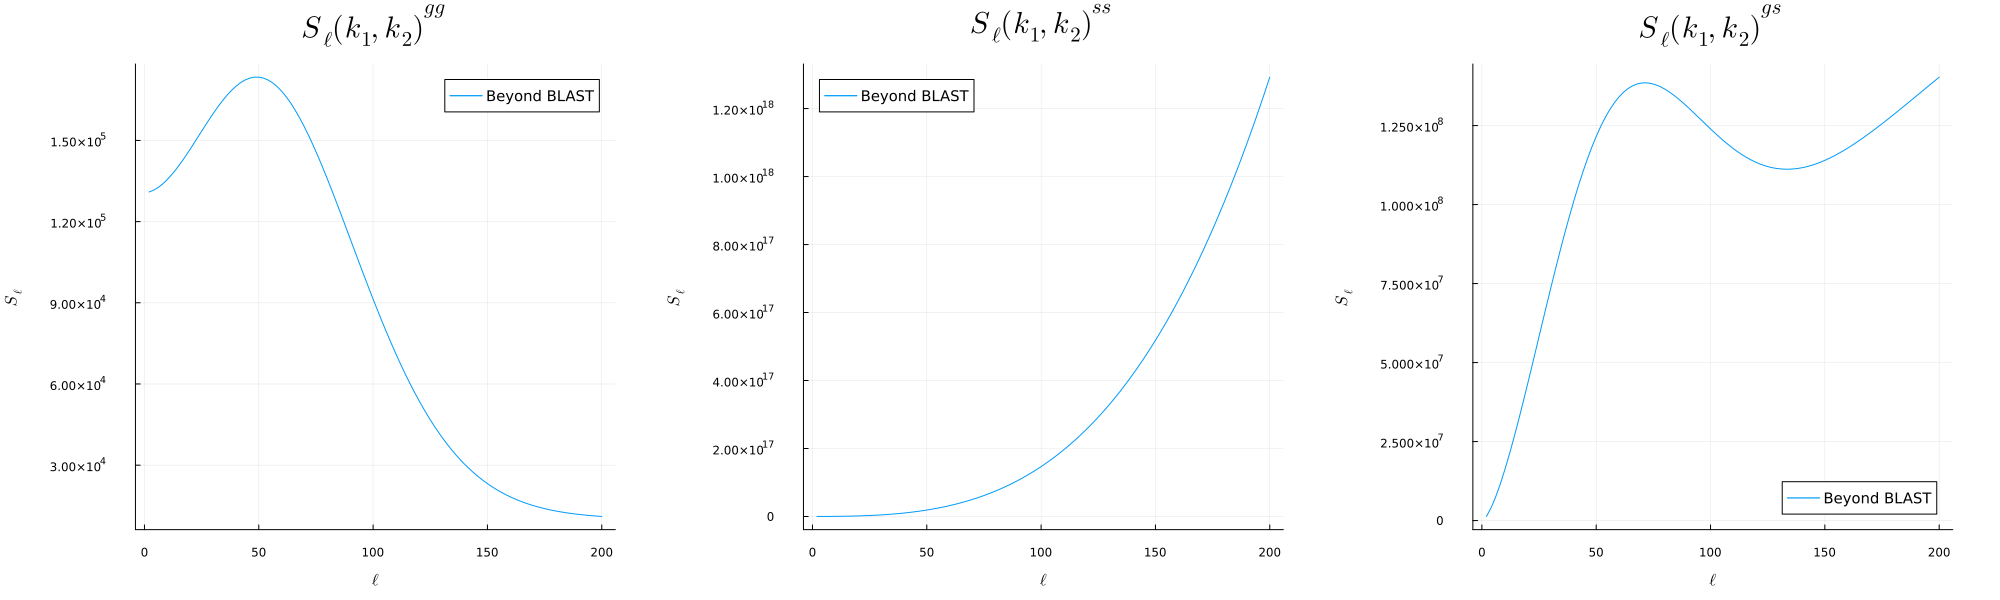

In [235]:
# plot
i = 1
j = 1
p1 =  plot(ℓ, S_lkk_gg[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gg}")
p2 =  plot(ℓ, S_lkk_ss[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{ss}")
p3 =  plot(ℓ, S_lkk_gs[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gs}")

plot(p1, p2, p3, layout = (1, 3), size=(2000, 600), titlefontsize=20, legendfontsize=10, margin = 10mm)

In [236]:
weight_kp = w_kp .* kp_grid .* kpp_grid   # pesi per k1 e k2
S_l_gg = zeros(Float64, length(ℓ))
@tullio S_l_gg[li] := weight_kp[kp] * S_lkk_gg[kp, kp, li]
S_l_ss = zeros(Float64, length(ℓ))
@tullio S_l_ss[li] := weight_kp[kp] * S_lkk_ss[kp, kpp, li];
S_l_gs = zeros(Float64, length(ℓ))
@tullio S_l_gs[li] := weight_kp[kp] * weight_kp[kpp] * S_lkk_gs[kp, kpp, li];

In [237]:
npzwrite(joinpath(quantity_subdir, "Sl/S_l_gg.npy"), S_l_gg)
npzwrite(joinpath(quantity_subdir, "Sl/S_l_ss.npy"), S_l_ss)
npzwrite(joinpath(quantity_subdir, "Sl/S_l_gs.npy"), S_l_gs);

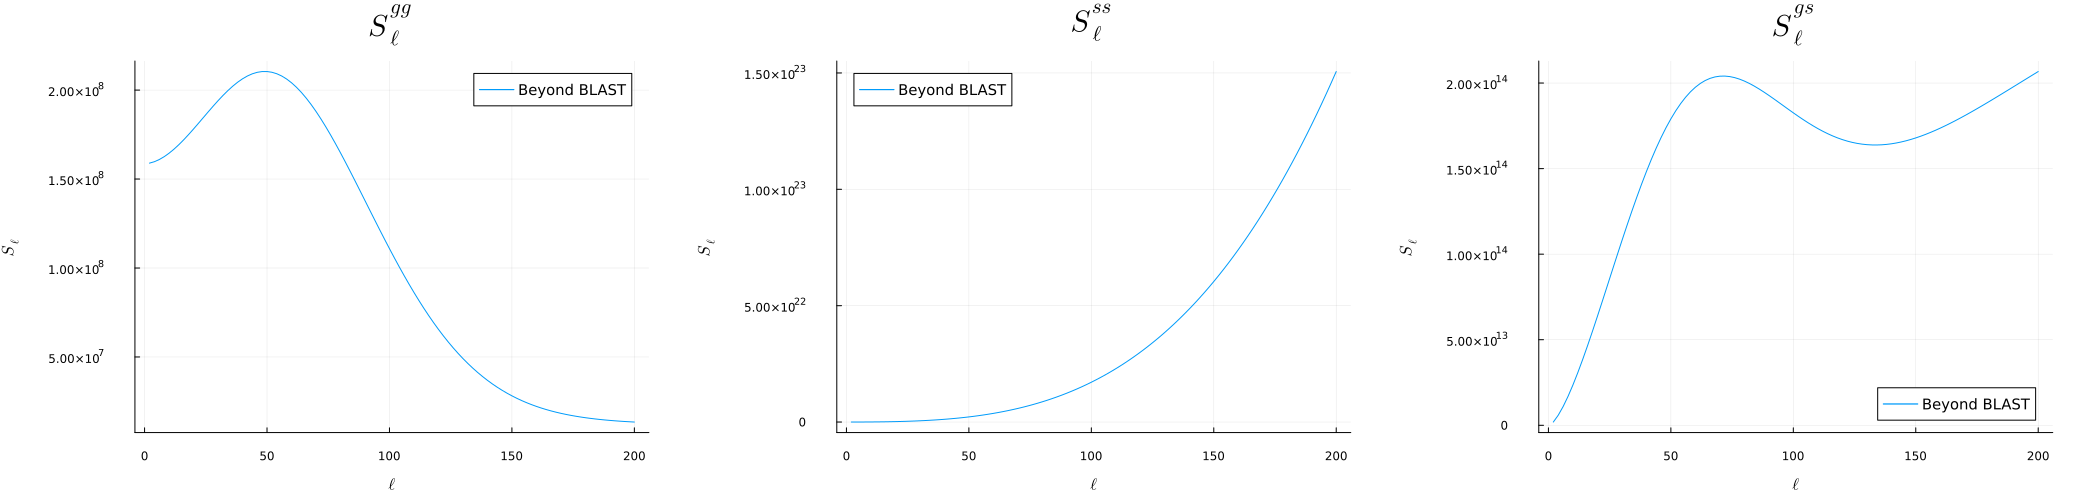

In [238]:
# plot
p1 =  plot(ℓ, S_l_gg, label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell^{gg}", size = (1400,800))
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gg.png"))
p2 =  plot(ℓ, S_l_ss, label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell^{ss}", size = (1400,800))
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_ss.png"))
p3 =  plot(ℓ, S_l_gs, label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell^{gs}", size = (1400,800))
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gs.png"))
plot(p1, p2, p3, layout = (1, 3), size=(2100, 500), titlefontsize=20, legendfontsize=10, margin = 10mm)

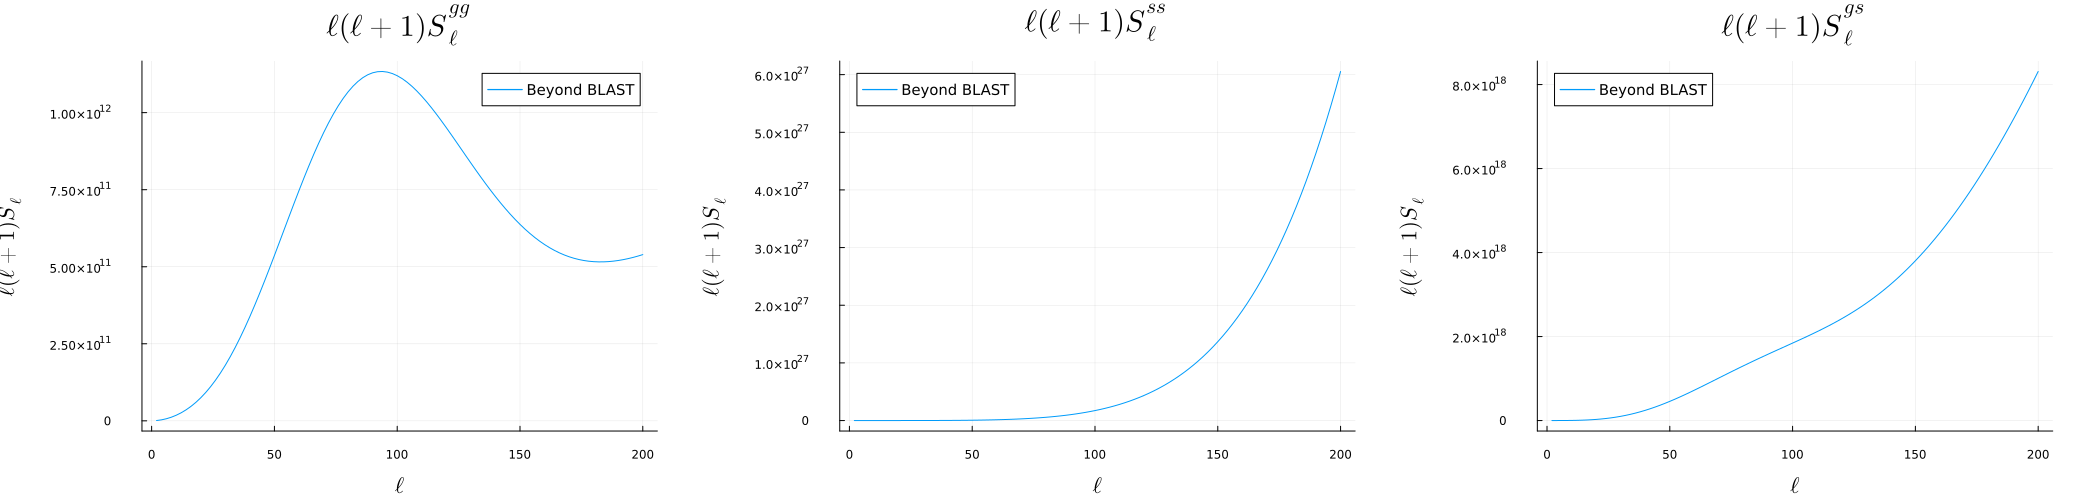

In [239]:
p1 = plot(
    ℓ,
    S_l_gg .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{gg}",
    markersize=4,
    size = (700, 500),
    titlefontsize=20,
    labelfontsize=15
)
p2 = plot(
    ℓ,
    S_l_ss .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{ss}",
    markersize=4,
    size = (700, 500),
    titlefontsize=20,
    labelfontsize=15
)
p3 = plot(
    ℓ,
    S_l_gs .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{gs}",
    markersize=4,
    size = (700, 500),
    titlefontsize=20,
    labelfontsize=15
) 
plot(p1, p2, p3, layout = (1, 3), size=(2100, 500), titlefontsize=20, legendfontsize=10, margin = 10mm)

In [240]:
p1 = plot(ℓ, S_l_gg .* ℓ .* (ℓ .+ 1), label = L"N = $2^{15}+1$ with optimized $\tilde W$", xlabel = L"\ell", ylabel = L"\ell(\ell+1)S_\ell", title = L"\ell(\ell+1)S_\ell (gg)",
          markersize=4, size = (1400, 800), titlefontsize=20, labelfontsize=15, dpi = 200)
savefig(joinpath(output_dir, "plots/Sl_plots/S_l_plot_gg_per_l.png"))
p2 = plot(ℓ, S_l_ss .* ℓ .* (ℓ .+ 1), label = L"N = $2^{15}+1$ with optimized $\tilde W$", xlabel = L"\ell", ylabel = L"\ell(\ell+1)S_\ell", title = L"\ell(\ell+1)S_\ell (ss)",
          markersize=4, size = (1400, 800), titlefontsize=20, labelfontsize=15, dpi = 200)
savefig(joinpath(output_dir, "plots/Sl_plots/S_l_plot_ss_per_l.png"))
p3 = plot(ℓ, S_l_gs .* ℓ .* (ℓ .+ 1), label = L"N = $2^{15}+1$ with optimized $\tilde W$", xlabel = L"\ell", ylabel = L"\ell(\ell+1)S_\ell", title = L"\ell(\ell+1)S_\ell (gs)",
          markersize=4, size = (1400, 800), titlefontsize=20, labelfontsize=15, dpi = 200)
savefig(joinpath(output_dir, "plots/Sl_plots/S_l_plot_gs_per_l.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_17_164210/plots/Sl_plots/S_l_plot_gs_per_l.png"

In [241]:
params_run = Dict(
    "x_min" => x_min,
    "x_max" => x_max,
    "n_chi" => n_chi,
    "zmin" => zmin,
    "zmax" => zmax,
    "kmin" => kmin,
    "kmax" => kmax,
    "n_cheb" => n_cheb,
    "N" => N,
    "ℓ" => length(ℓ)
)

open(joinpath(output_dir, "config.json"), "w") do io
    JSON.print(io, params_run, 4) # Scrive il dizionario in formato JSON pulito
end

println("Data brought to safety in folder: ", output_dir)

Data brought to safety in folder: out/runs/run_2026_06_17_164210
